In [255]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt


In [256]:
data = pd.read_csv('bengaluru_house_prices.csv')
data.head(10)

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
5,Super built-up Area,Ready To Move,Whitefield,2 BHK,DuenaTa,1170,2.0,1.0,38.00
6,Super built-up Area,18-May,Old Airport Road,4 BHK,Jaades,2732,4.0,NaN,204.00
7,Super built-up Area,Ready To Move,Rajaji Nagar,4 BHK,Brway G,3300,4.0,NaN,600.00
8,Super built-up Area,Ready To Move,Marathahalli,3 BHK,NaN,1310,3.0,1.0,63.25
9,Plot Area,Ready To Move,Gandhi Bazar,6 Bedroom,NaN,1020,6.0,NaN,370.00


In [257]:
data.describe()

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


In [258]:
data.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [259]:
data["location"].value_counts()

location
Whitefield                                         540
Sarjapur  Road                                     399
Electronic City                                    302
Kanakpura Road                                     273
Thanisandra                                        234
                                                  ... 
Pattegarhpalya                                       1
Tilak Nagar                                          1
12th cross srinivas nagar banshankari 3rd stage      1
Havanur extension                                    1
Abshot Layout                                        1
Name: count, Length: 1305, dtype: int64

In [260]:
data["area_type"].value_counts()

area_type
Super built-up  Area    8790
Built-up  Area          2418
Plot  Area              2025
Carpet  Area              87
Name: count, dtype: int64

<Figure size 1200x800 with 0 Axes>

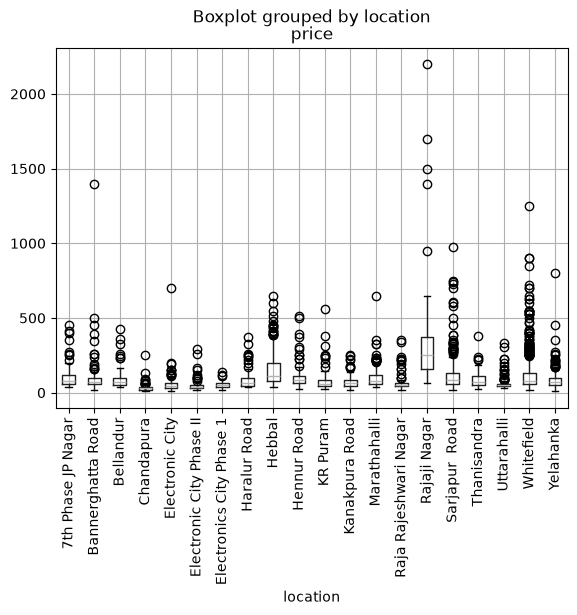

In [261]:
top_locations = data["location"].value_counts().head(20).index

temp = data[data["location"].isin(top_locations)]

plt.figure(figsize=(12, 8))
temp.boxplot(column="price", by="location")
plt.xticks(rotation=90)
plt.show()

In [262]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  str    
 1   availability  13320 non-null  str    
 2   location      13319 non-null  str    
 3   size          13304 non-null  str    
 4   society       7818 non-null   str    
 5   total_sqft    13320 non-null  str    
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), str(6)
memory usage: 936.7 KB


In [263]:
data["bath"] = data["bath"].fillna(data["bath"].mean())
data["balcony"] = data["balcony"].fillna(data["balcony"].min())
data


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.00
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,0.0,400.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.00
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.00


In [264]:
data["size"].value_counts()

size
2 BHK         5199
3 BHK         4310
4 Bedroom      826
4 BHK          591
3 Bedroom      547
1 BHK          538
2 Bedroom      329
5 Bedroom      297
6 Bedroom      191
1 Bedroom      105
8 Bedroom       84
7 Bedroom       83
5 BHK           59
9 Bedroom       46
6 BHK           30
7 BHK           17
1 RK            13
10 Bedroom      12
9 BHK            8
8 BHK            5
11 BHK           2
11 Bedroom       2
10 BHK           2
27 BHK           1
19 BHK           1
16 BHK           1
43 Bedroom       1
14 BHK           1
12 Bedroom       1
13 BHK           1
18 Bedroom       1
Name: count, dtype: int64

In [265]:
data["bhk"] = data["size"].str.extract(r"(\d+)").astype(float)
data["bhk"].mean()

np.float64(2.803743235117258)

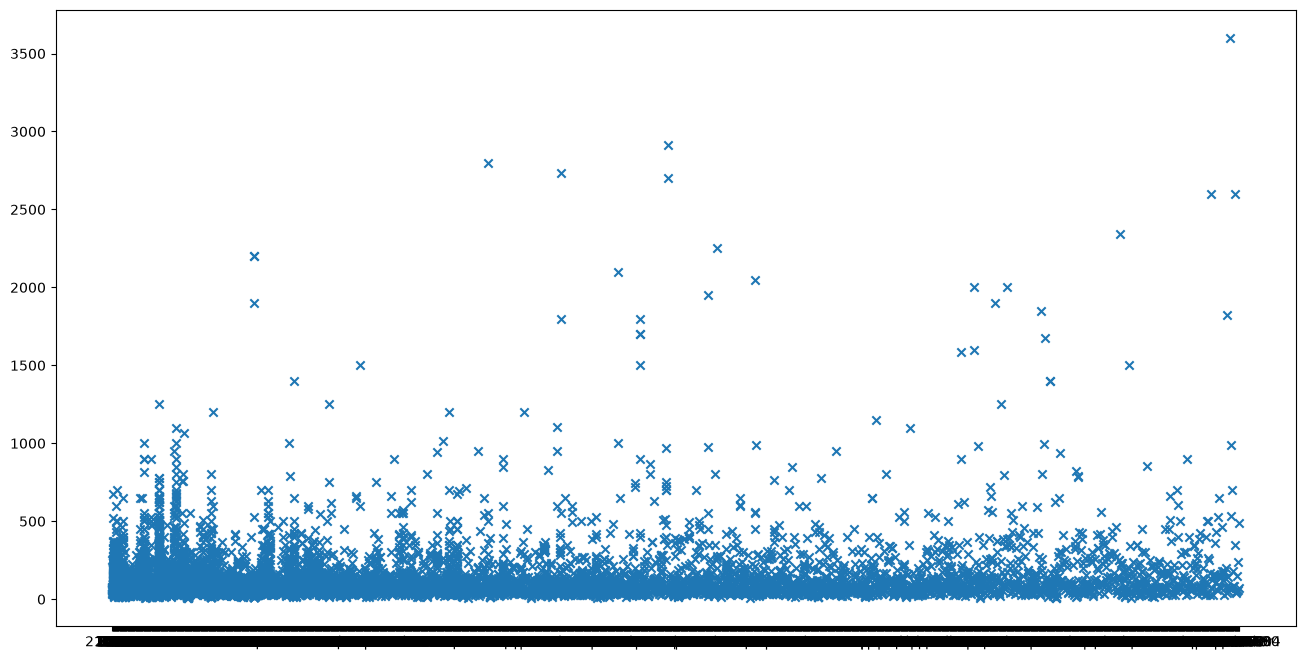

In [266]:
plt.figure(figsize=(16,8))
plt.scatter(data["total_sqft"],data["price"],marker='x')

In [267]:
data["balcony"].isnull().sum()

np.int64(0)

In [268]:
def convert_sqft(x):
    try:
        if "-" in x:
            tokens = x.split("-")
            return (float(tokens[0]) + float(tokens[1])) / 2
        
        if "Sq. Meter" in x:
            return float(x.split("Sq. Meter")[0]) * 10.7639
        
        return float(x)
    
    except:
        return None

In [269]:
data["total_sqft"] = data["total_sqft"].apply(convert_sqft)



In [270]:
data["sqft_per_bhk"] = data["total_sqft"] / data["bhk"]

In [271]:
data[["total_sqft", "bhk", "sqft_per_bhk"]].head()

,total_sqft,bhk,sqft_per_bhk
0,1056.0,2.0,528.0
1,2600.0,4.0,650.0
2,1440.0,3.0,480.0
3,1521.0,3.0,507.0
4,1200.0,2.0,600.0


In [272]:
data.drop("size", axis=1, inplace=True)
data.head(10)

,area_type,availability,location,society,total_sqft,bath,balcony,price,bhk,sqft_per_bhk
0,Super built-up Area,19-Dec,Electronic City Phase II,Coomee,1056.0,2.0,1.0,39.07,2.0,528.000000
1,Plot Area,Ready To Move,Chikka Tirupathi,Theanmp,2600.0,5.0,3.0,120.00,4.0,650.000000
2,Built-up Area,Ready To Move,Uttarahalli,NaN,1440.0,2.0,3.0,62.00,3.0,480.000000
3,Super built-up Area,Ready To Move,Lingadheeranahalli,Soiewre,1521.0,3.0,1.0,95.00,3.0,507.000000
4,Super built-up Area,Ready To Move,Kothanur,NaN,1200.0,2.0,1.0,51.00,2.0,600.000000
5,Super built-up Area,Ready To Move,Whitefield,DuenaTa,1170.0,2.0,1.0,38.00,2.0,585.000000
6,Super built-up Area,18-May,Old Airport Road,Jaades,2732.0,4.0,0.0,204.00,4.0,683.000000
7,Super built-up Area,Ready To Move,Rajaji Nagar,Brway G,3300.0,4.0,0.0,600.00,4.0,825.000000
8,Super built-up Area,Ready To Move,Marathahalli,NaN,1310.0,3.0,1.0,63.25,3.0,436.666667
9,Plot Area,Ready To Move,Gandhi Bazar,NaN,1020.0,6.0,0.0,370.00,6.0,170.000000


In [273]:
data.drop("society", axis=1, inplace=True) 

In [274]:
data

,area_type,availability,location,total_sqft,bath,balcony,price,bhk,sqft_per_bhk
0,Super built-up Area,19-Dec,Electronic City Phase II,1056.0,2.0,1.0,39.07,2.0,528.00
1,Plot Area,Ready To Move,Chikka Tirupathi,2600.0,5.0,3.0,120.00,4.0,650.00
2,Built-up Area,Ready To Move,Uttarahalli,1440.0,2.0,3.0,62.00,3.0,480.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,1521.0,3.0,1.0,95.00,3.0,507.00
4,Super built-up Area,Ready To Move,Kothanur,1200.0,2.0,1.0,51.00,2.0,600.00
...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,3453.0,4.0,0.0,231.00,5.0,690.60
13316,Super built-up Area,Ready To Move,Richards Town,3600.0,5.0,0.0,400.00,4.0,900.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,1141.0,2.0,1.0,60.00,2.0,570.50
13318,Super built-up Area,18-Jun,Padmanabhanagar,4689.0,4.0,1.0,488.00,4.0,1172.25


In [275]:
data["location"].value_counts().head(20)

location
Whitefield                  540
Sarjapur  Road              399
Electronic City             302
Kanakpura Road              273
Thanisandra                 234
Yelahanka                   213
Uttarahalli                 186
Hebbal                      177
Marathahalli                175
Raja Rajeshwari Nagar       171
Hennur Road                 152
Bannerghatta Road           152
7th Phase JP Nagar          149
Haralur Road                142
Electronic City Phase II    132
Rajaji Nagar                107
Chandapura                  100
Bellandur                    96
KR Puram                     91
Electronics City Phase 1     88
Name: count, dtype: int64

In [276]:
data["location"] = data["location"].fillna("other")
location_counts = data["location"].value_counts()

data["location"] = data["location"].apply(
    lambda x: "other" if location_counts[x] <= 10 else x
)

In [277]:
data["location"].nunique()

242

In [278]:
data = pd.get_dummies(data,
                     columns=["location"],
                     dtype=int)

In [279]:
data["area_type"].value_counts()

area_type
Super built-up  Area    8790
Built-up  Area          2418
Plot  Area              2025
Carpet  Area              87
Name: count, dtype: int64

In [280]:
data = pd.get_dummies(data, columns=["area_type"], dtype=int)


In [281]:
data["availability"].value_counts().head(20)

availability
Ready To Move    10581
18-Dec             307
18-May             295
18-Apr             271
18-Aug             200
19-Dec             185
18-Jul             143
18-Mar             131
18-Jun              99
20-Dec              98
21-Dec              93
19-Mar              88
18-Feb              62
18-Nov              47
18-Jan              43
18-Sep              41
19-Jun              40
18-Oct              39
19-Jan              39
19-Jul              36
Name: count, dtype: int64

In [282]:
data.drop("availability", axis = 1, inplace = True)

In [283]:
data 

,total_sqft,bath,balcony,price,bhk,sqft_per_bhk,location_ Devarachikkanahalli,location_1st Block Jayanagar,location_1st Phase JP Nagar,location_2nd Phase Judicial Layout,...,location_Yelachenahalli,location_Yelahanka,location_Yelahanka New Town,location_Yelenahalli,location_Yeshwanthpur,location_other,area_type_Built-up Area,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area
0,1056.0,2.0,1.0,39.07,2.0,528.00,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,2600.0,5.0,3.0,120.00,4.0,650.00,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,1440.0,2.0,3.0,62.00,3.0,480.00,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,1521.0,3.0,1.0,95.00,3.0,507.00,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,1200.0,2.0,1.0,51.00,2.0,600.00,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13315,3453.0,4.0,0.0,231.00,5.0,690.60,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
13316,3600.0,5.0,0.0,400.00,4.0,900.00,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
13317,1141.0,2.0,1.0,60.00,2.0,570.50,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
13318,4689.0,4.0,1.0,488.00,4.0,1172.25,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [284]:
data.columns

Index(['total_sqft', 'bath', 'balcony', 'price', 'bhk', 'sqft_per_bhk',
       'location_ Devarachikkanahalli', 'location_1st Block Jayanagar',
       'location_1st Phase JP Nagar', 'location_2nd Phase Judicial Layout',
       ...
       'location_Yelachenahalli', 'location_Yelahanka',
       'location_Yelahanka New Town', 'location_Yelenahalli',
       'location_Yeshwanthpur', 'location_other', 'area_type_Built-up  Area',
       'area_type_Carpet  Area', 'area_type_Plot  Area',
       'area_type_Super built-up  Area'],
      dtype='str', length=252)

In [297]:
numeric_cols = ["total_sqft", "bhk", "bath", "balcony", "sqft_per_bhk"]

for col in numeric_cols:
    data[col] = data[col].fillna(data[col].median())

In [298]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
X = data.drop("price",axis = 1)
y = data["price"]

In [299]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)



In [300]:
y_test.shape


(2664,)

In [301]:
y_train.shape

(10656,)

In [302]:
X_train.shape

(10656, 251)

In [303]:
X_test.shape

(2664, 251)

In [304]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ["total_sqft", "bhk", "bath", "balcony", "sqft_per_bhk"]

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(
    X_train[numeric_cols]
)

X_test_scaled[numeric_cols] = scaler.transform(
    X_test[numeric_cols]
)

In [311]:
model = LinearRegression()
model.fit(X_train_scaled,y_train)
y_pred = model.predict(X_test_scaled)
y_pred 





array([-17.727463  ,  97.72352425,  87.80523133, ..., 103.29221332,
        84.36378585, 160.30389956], shape=(2664,))

In [313]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2 Score:", r2)

MSE: 9326.79096147857
R2 Score: 0.5619278895750942


In [314]:
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE:", rmse)

RMSE: 96.57531238095257


In [315]:
print(y_test[:10])
print(y_pred[:10])

8077      64.8
1602     125.0
10498     60.0
3297     110.0
8893     210.0
542       90.0
12411     65.0
8522      35.0
12763     48.0
487       49.0
Name: price, dtype: float64
[-17.727463    97.72352425  87.80523133 135.47550529 132.62228509
  80.64272832  85.88291971  39.30825815 115.78653534  71.66741024]
